In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from config import KAGGLE_CSV, SWMH_TEST_CSV, SWMH_TRAIN_CSV, SWMH_VAL_CSV, SEED

Kaggle Dataset

In [3]:
kaggle_df = pd.read_csv(KAGGLE_CSV)

In [ ]:
print('Shape: ', kaggle_df.shape)
print('Columns: ', kaggle_df.columns)
print('Missing values: ', kaggle_df.isna().sum())
print('Duplicate Rows: ', kaggle_df.duplicated().sum())
print('Duplicate Texts: ', kaggle_df['text'].duplicated().sum())

Shape:  (232074, 3)
Columns:  Index(['Unnamed: 0', 'text', 'class'], dtype='str')
Missing values:  Unnamed: 0    0
text          0
class         0
dtype: int64
Duplicate:  0
Duplicate Texts:  0
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [15]:
for c in kaggle_df['class'].unique():
    print(f"\n--- {c} ---")
    for t in kaggle_df[kaggle_df['class']==c]['text'].sample(3, random_state=SEED):
        print(t[:300], "\n")


--- suicide ---
Todays the day..I've got the thing I'll h*ng myself with. I'm just procrastinating.... I'm scared, and I just feel guilty. I couldnt sleep last night I kept thinking about who will find me just hanging there... it saddens me I have to leave this world like this 

Bad luckThis is my first post on Reddit ever. I've had many concussions resulting from different sports and also very bad luck. I can't really complain about the life I had: I had pretty much straight A's in building engineering, I have a large group of friends, my family is very supportive and lovi 

just had a severe ptsd attack and idk how to cope with it so here i am crying my eyes out at 6 am on the floor thinking to kill myself to ease my paini hate you just get the fuck out of my skin 


--- non-suicide ---
Used to keep it cool Used to be a fool 

All about the bounce in my step

Watch it on the news

Watchya gonna do

I could hit refresh and forget

Used to keep it cool

*epic trumpet noises* 

Well, h

class
suicide        116037
non-suicide    116037
Name: count, dtype: int64


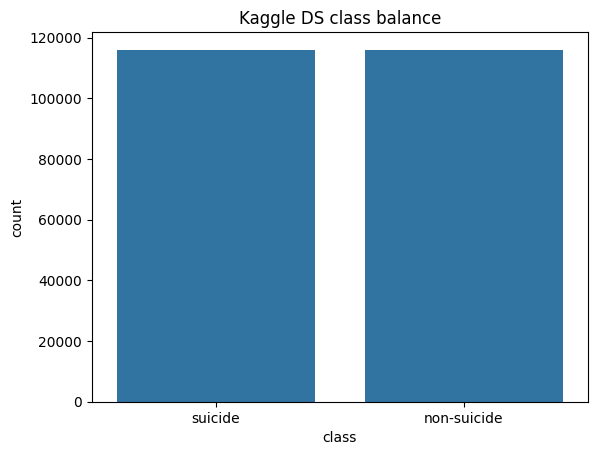

In [ ]:
#Class Balance Analysis
print(kaggle_df['class'].value_counts())
sns.countplot(data=kaggle_df, x='class')
plt.title("Kaggle DS class balance")
plt.show()

In [ ]:
#Text Length Analysis
kaggle_df['char_len'] = kaggle_df['text'].str.len()
kaggle_df['word_len'] = kaggle_df['text'].str.split().str.len()

print(kaggle_df[['char_len','word_len']].describe(percentiles=[.5,.9,.95,.99]))


            char_len       word_len
count  232074.000000  232074.000000
mean      689.639736     131.925235
std      1156.334007     217.476787
min         3.000000       1.000000
50%       315.000000      60.000000
90%      1653.000000     318.000000
95%      2457.000000     471.000000
99%      5062.270000     963.000000
max     40297.000000    9684.000000


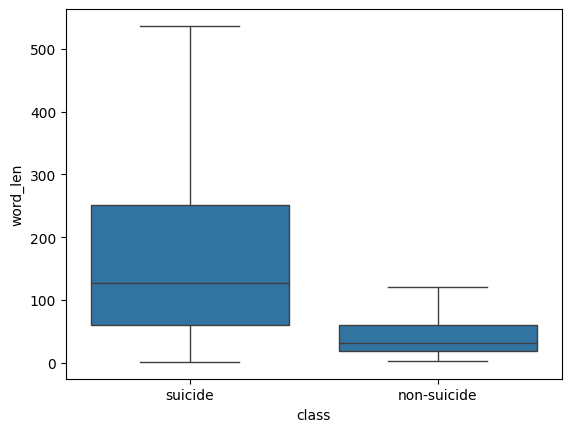

In [12]:
sns.boxplot(data=kaggle_df, x='class', y='word_len', showfliers=False)
plt.show()

In [8]:
empty = kaggle_df['text'].str.strip().eq('') | kaggle_df['text'].isna()
print("Empty/whitespace rows:", empty.sum())
print("Very short (<3 words):", (kaggle_df['word_len'] < 3).sum())
print("Very long (>p99):", (kaggle_df['word_len'] > kaggle_df['word_len'].quantile(.99)).sum())

Empty/whitespace rows: 0
Very short (<3 words): 186
Very long (>p99): 2319


In [9]:
conflict = kaggle_df.groupby('text')['class'].nunique()
print("Texts with conflicting labels:", (conflict > 1).sum())

Texts with conflicting labels: 0


In [ ]:
#Noise Analysis
patterns = {
    'url':     r'http\S+|www\.\S+',
    'mention': r'@\w+',
    'hashtag': r'#\w+',
    'number':  r'\b\d+\b',
    'upper':   r'\b[A-Z]{3,}\b',
}

for name, pat in patterns.items():
    hits = kaggle_df['text'].str.contains(pat, regex=True, na=False).mean()
    print(f"{name:8s}: {hits:.2%} of rows")

url     : 3.10% of rows
mention : 0.03% of rows
hashtag : 2.09% of rows
number  : 35.09% of rows
upper   : 14.41% of rows


SWMH Dataset

In [18]:
swmh_train = pd.read_csv(SWMH_TRAIN_CSV)
swmh_val = pd.read_csv(SWMH_VAL_CSV)
swmh_test = pd.read_csv(SWMH_TEST_CSV)

In [21]:
swmh_train['split'] = 'train'
swmh_val['split']   = 'val'
swmh_test['split']  = 'test'
swmh_df = pd.concat([swmh_train, swmh_val, swmh_test], ignore_index=True)

In [22]:
print('Shape: ', swmh_df.shape)
print('Columns: ', swmh_df.columns)
print('Missing values: ', swmh_df.isna().sum())
print('Duplicate: ', swmh_df.duplicated().sum())
print('Duplicate Texts: ', swmh_df['text'].duplicated().sum())

Shape:  (54412, 3)
Columns:  Index(['text', 'label', 'split'], dtype='str')
Missing values:  text     0
label    0
split    0
dtype: int64
Duplicate:  25
Duplicate Texts:  113


In [25]:
for lvl in swmh_df['label'].unique():
    print(f"\n--- {lvl} ---")
    for t in swmh_df[swmh_df['label']==lvl]['text'].sample(3, random_state=SEED):
        print(t[:300], "\n")


--- self.Anxiety ---
I constantly think about my job Basically what title says - I am currently on a sick leave and I cannot stop thinking about my job. I cannot watch TV, I cannot play games, it just feels weird that I'm at home and everyone's in job. I'm 25. I always used to overthink but this one is killing me... 

Questions about my meds? mirtazapine I have been on Mirtazapine since November. I started out on 15mg and that helped me knock out to sleep but during the day I still felt like my anxious self. My Dr decided to up my dosage to 30mg. So far it has been great. I've slept better than ever without night 

Holy Shit. Is this what Anxiety feels like? Guys, I'm so sorry. Bit of a backstory. I’m a 30 year-old male who has never had a history of anxiety. Sure, I’d get stressed on occasion but I always knew how to cope when I did. In fact, I’d go as far as to say I was almost too laid back. Nothing ever re 


--- self.bipolar ---
22[F] My mom is fed up with me, says I'm a failure,

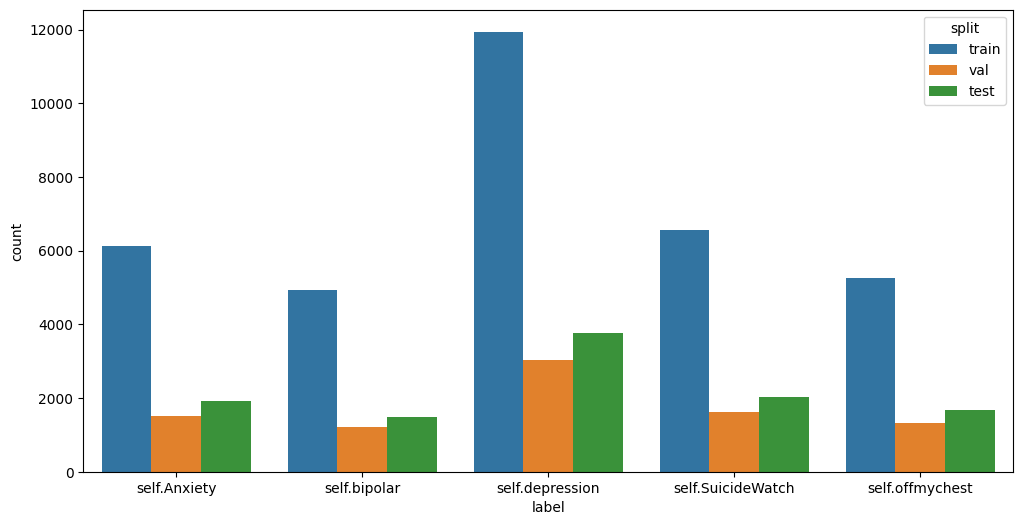

In [ ]:
#Class Balance Analysis
plt.figure(figsize=(12,6))
sns.countplot(swmh_df, x='label', hue='split')
plt.show()

In [33]:
#Text Length Analysis
swmh_df['char_len'] = swmh_df['text'].str.len()
swmh_df['word_len'] = swmh_df['text'].str.split().str.len()

print(swmh_df[['char_len','word_len']].describe(percentiles=[.5,.9,.95,.99]))

           char_len      word_len
count  54412.000000  54412.000000
mean     932.767753    178.075902
std     1239.093892    236.796956
min       36.000000     10.000000
50%      565.000000    108.000000
90%     2136.900000    409.000000
95%     2996.000000    572.000000
99%     5893.000000   1121.000000
max    36729.000000   6782.000000


In [ ]:
#Split Leakage Analysis
train_set = set(swmh_train['text'])
val_leak  = swmh_val['text'].isin(train_set).sum()
test_leak = swmh_test['text'].isin(train_set).sum()
print(f"Val rows that appear in train: {val_leak}")
print(f"Test rows that appear in train: {test_leak}")

Val rows that appear in train: 25
Test rows that appear in train: 23
Texts with conflicting labels: 65


In [32]:
#Conflicting Label Analysis
conflict = swmh_df.groupby('text')['label'].nunique()
print("Texts with conflicting labels:", (conflict > 1).sum())

Texts with conflicting labels: 65


In [35]:
empty = swmh_df['text'].str.strip().eq('') | swmh_df['text'].isna()
print("Empty/whitespace rows:", empty.sum())
print("Very short (<3 words):", (swmh_df['word_len'] < 3).sum())
print("Very long (>p99):", (swmh_df['word_len'] > swmh_df['word_len'].quantile(.99)).sum())

Empty/whitespace rows: 0
Very short (<3 words): 0
Very long (>p99): 543


In [34]:
#Noise Analysis
for name, pat in patterns.items():
    hits = swmh_df['text'].str.contains(pat, regex=True, na=False).mean()
    print(f"{name:8s}: {hits:.2%}")

url     : 1.08%
mention : 0.05%
hashtag : 0.30%
number  : 38.77%
upper   : 17.68%
